In [17]:
import numpy as np
from numba import njit

from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
SEEDS = np.random.randint(100000, size=20)

Самые вычислительно сложные функции скомпилируем отдельно при помощи numba

In [3]:
@njit
def calc_energy_jit(spins: np.ndarray) -> int:
    L = spins.shape[0]
    energy = 0
    for i in range(L):
        for j in range(L):
            cur_s = spins[i, j]
            energy -= cur_s * spins[(i + 1) % L, j]
            energy -= cur_s * spins[i, (j + 1) % L]

    return energy

In [4]:
@njit
def calc_magnetization_jit(spins: np.ndarray) -> int:
    L = spins.shape[0]
    magnetization = 0
    for i in range(L):
        for j in range(L):
            magnetization += spins[i, j]

    return magnetization

In [5]:
@njit
def calc_delta_H_jit(spins: np.ndarray, i: int, j : int) -> int:
    L = spins.shape[0]
    neighbors = (
        spins[(i + 1) % L , j]
        + spins[(i - 1) % L, j]
        + spins[i, (j + 1) % L]
        + spins[i, (j - 1) % L]
    )
    return 2 * spins[i, j] * neighbors

In [6]:
@njit
def one_sweep_jit(spins: np.ndarray, beta: float, gen) -> None:
    L = spins.shape[0]
    for _ in range(L * L):
        r_i = gen.integers(0, L)
        r_j = gen.integers(0, L)
        dH = calc_delta_H_jit(spins, r_i, r_j)
        if dH < 0 or gen.random() <= np.exp(-beta * dH):
            spins[r_i, r_j] *= -1

In [7]:
@njit
def experiment_jit(
        spins: np.ndarray,
        beta: float,
        num_samples: int,
        thermalization_sweeps: int,
        gen
) -> tuple[int, int, int]:

    L = spins.shape[0]

    for _ in range(thermalization_sweeps):
        one_sweep_jit(spins, beta, gen)

    sum_E, sum_M, sum_abs_M = 0, 0, 0
    for _ in range(num_samples):
        one_sweep_jit(spins, beta, gen)

        sum_E += calc_energy_jit(spins)

        cur_magnetization = calc_magnetization_jit(spins)
        sum_M += cur_magnetization
        sum_abs_M += abs(cur_magnetization)

    return (
        sum_E / (L ** 2 * num_samples),
        sum_M / (L ** 2 * num_samples),
        sum_abs_M / (L ** 2 * num_samples)
    )

Класс **IsingModel** отвечает за таблицу спинов и все действия, которые с ней совершаются

In [8]:
class IsingModel:

    def __init__(
            self,
            L: int,
            *,
            seed: int = 42
        ) -> None:
        self.size = L # размер решётки
        self.rng = np.random.default_rng(seed)
        self.spins = self.rng.choice([-1, 1], size=(L, L)).astype(np.int8) # матрица спинов

    def calc_delta_H(self, i: int, j: int) -> int:
        """Вычислить изменение энергии в случае переворота спина (i, j)"""
        return calc_delta_H_jit(self.splins, i, j)

    def calc_energy(self) -> int:
        """Вычислить полную энергию решётки"""
        return calc_energy_jit(self.spins)

    def calc_magnetization(self) -> int:
        """Вычислить полную намагниченность решётки"""
        return calc_magnetization_jit(self.spins)

Класс **MetropolisSampler** принимает на вход таблицу спинов и температуру, после чего проводит серию эксперимент и возвращает нормированные значения полной энергии и намагниченности

In [9]:
class MetropolisSampler:

    def __init__(
            self,
            model: IsingModel,
            beta: float,
            *,
            thermalization_sweeps: int = 10000,
            num_samples: int = 100,
            seed: int = 42
        ) -> None:
        self.ising_model = model
        self.beta = beta
        self.thermalization_sweeps = thermalization_sweeps # время релаксации
        self.num_samples = num_samples # число итераций в эксперименте
        self.rng = np.random.default_rng(seed) # генератор случайных чисел

    def one_sweep(self) -> None:
        """Выполнить один полный проход обновлений в алгоритме Метрополиса"""
        one_sweep_jit(self.ising_model.spins, self.beta, self.rng)

    def experiment(self) -> tuple[float, float, float]:
        """Провести эксперимент с заданными L и T"""
        return experiment_jit(
            self.ising_model.spins,
            self.beta,
            self.num_samples,
            self.thermalization_sweeps,
            self.rng
        )

In [10]:
# шкала температур
T = 2.269
series_T = np.linspace(T - 0.3, T + 0.3, 20)

In [15]:
# число экспериментов между сохранениями
samples = np.linspace(1000, 7000, 7, dtype=int)

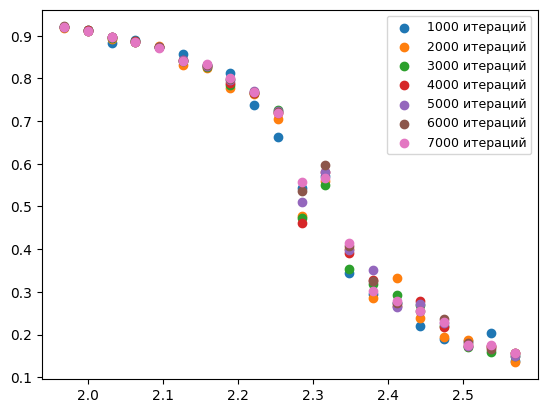

In [19]:
# тестирование решёток 32 x 32 с разным числом экспериментов
magnetization = defaultdict(list)
for n in samples:
    for t in series_T:
        model = IsingModel(32)
        sampler = MetropolisSampler(
            model,
            1 / t,
            num_samples=n
        )

        res = sampler.experiment()
        magnetization[n].append(res[2])

    plt.scatter(series_T, magnetization[n], label=f'{n} итераций')

plt.legend(fontsize=9, frameon=True)
plt.show()

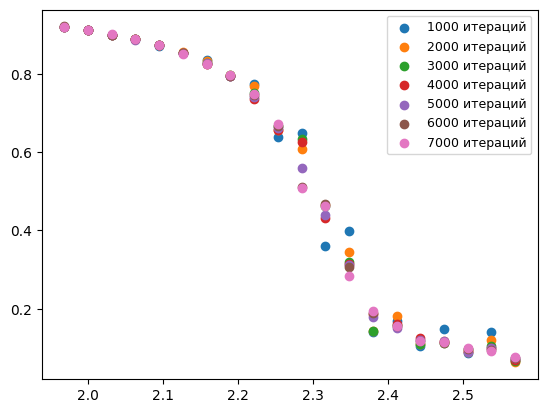

In [20]:
# тестирование решёток 64 x 64 с разным числом экспериментов
magnetization = defaultdict(list)
for n in samples:
    for t in series_T:
        model = IsingModel(64)
        sampler = MetropolisSampler(
            model,
            1 / t,
            num_samples=n
        )

        res = sampler.experiment()
        magnetization[n].append(res[2])

    plt.scatter(series_T, magnetization[n], label=f'{n} итераций')

plt.legend(fontsize=9, frameon=True)
plt.show()

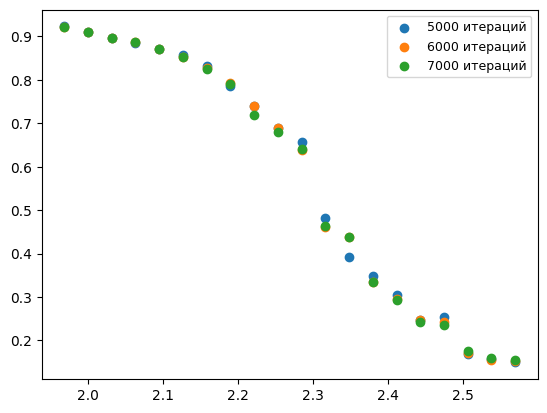

In [12]:
plt.scatter(series_T, magnetization_500, label='5000 итераций')
plt.scatter(series_T, magnetization_1000, label='6000 итераций')
plt.scatter(series_T, magnetization_1500, label='7000 итераций')


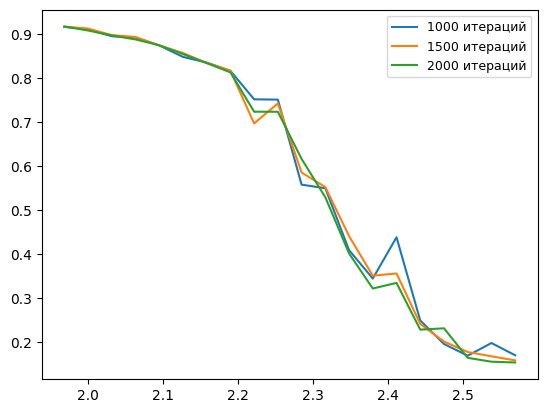

In [38]:
plt.plot(series_T, magnetization_500, label='1000 итераций')
plt.plot(series_T, magnetization_1000, label='1500 итераций')
plt.plot(series_T, magnetization_1500, label='2000 итераций')
plt.legend(fontsize=9, frameon=True)
plt.show()

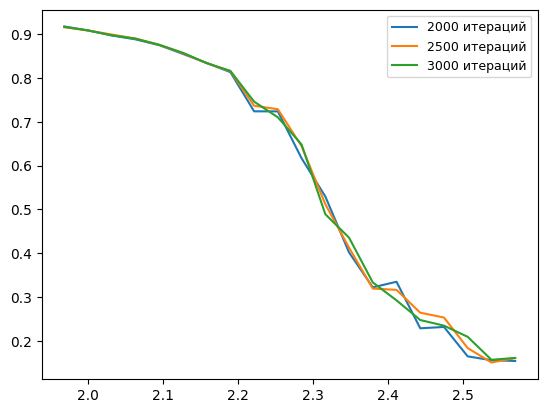

In [40]:
plt.plot(series_T, magnetization_500, label='2000 итераций')
plt.plot(series_T, magnetization_1000, label='2500 итераций')
plt.plot(series_T, magnetization_1500, label='3000 итераций')
plt.legend(fontsize=9, frameon=True)
plt.show()